# scIDiff Tutorial: Paul15 Hematopoietic Differentiation

This notebook demonstrates **scIDiff with RNA velocity** on the classic Paul et al. 2015 hematopoiesis dataset.

## Dataset Overview

- **~2,730 mouse bone marrow cells**
- **~3,000 genes**
- Captures **myeloid differentiation** (HSC → progenitors → mature lineages)
- Clear **branching structure** ideal for trajectory inference

## What We'll Do

1. Load and preprocess the Paul15 dataset
2. Compute RNA velocity with scVelo
3. Train scIDiff **without** velocity (baseline)
4. Train scIDiff **with** velocity as biological prior
5. Compare drift fields and Jacobians
6. Visualize trajectories and regulatory archetypes
7. Quantify irreversibility

In [1]:
#!pip install --user scikit-misc
#!pip install scvelo

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvelo as scv
import torch

# scIDiff imports
import sys
sys.path.append('..')
from scqdiff.io.anndata import tensors_from_anndata
from scqdiff.models.drift import DriftField, DriftConfig

# Settings
sc.settings.verbosity = 2
scv.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor='white')

# Random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

/Users/terooatt/miniconda3/envs/scidiff/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


PyTorch version: 2.9.0
Device: cpu


## 1. Load and Preprocess Data

In [3]:
# Load Paul15 dataset
adata = sc.datasets.paul15()
print(f"Loaded {adata.n_obs} cells × {adata.n_vars} genes")
adata

Loaded 2730 cells × 3451 genes


AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

In [4]:
# Standard preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()  # Save raw data

# Feature selection
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')
print(f"Selected {adata.var.highly_variable.sum()} highly variable genes")

# Keep only HVGs for downstream analysis
adata = adata[:, adata.var.highly_variable].copy()

# Scale and PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
Selected 2000 highly variable genes
computing PCA
    with n_comps=30
    finished (0:00:00)


computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:05)
computing UMAP
    finished (0:00:03)


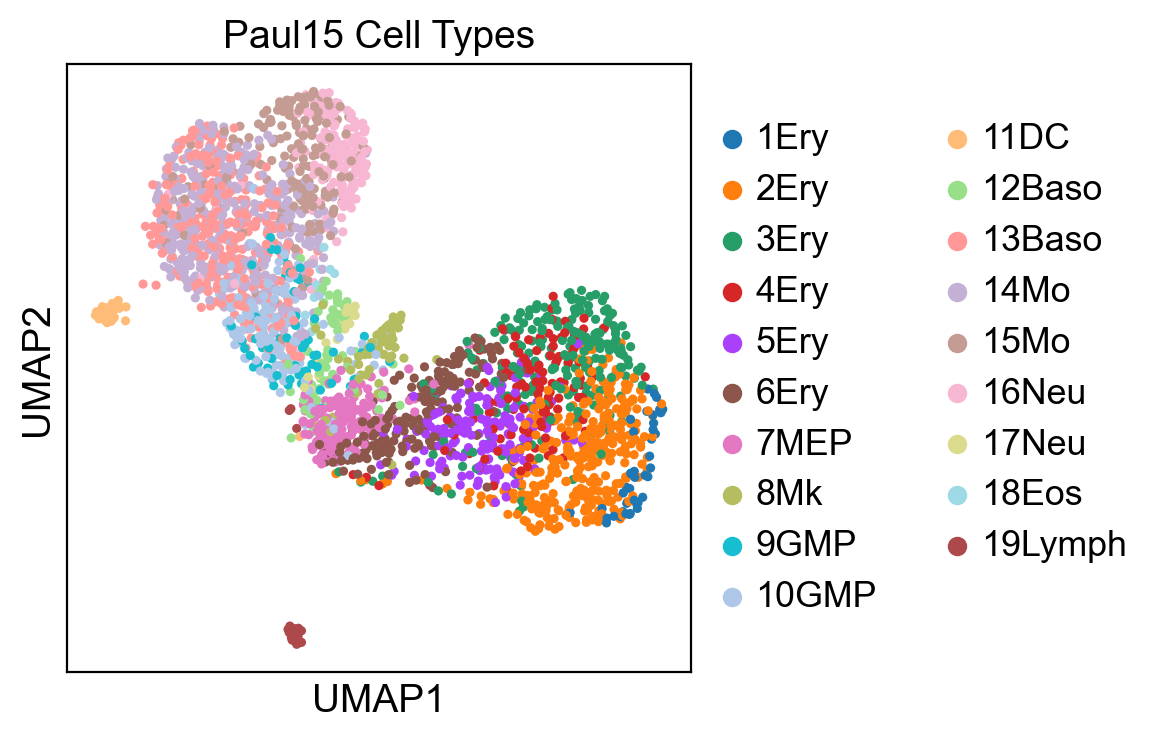

In [5]:
# Compute neighborhood graph and UMAP
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

# Visualize
sc.pl.umap(adata, color=['paul15_clusters'], title='Paul15 Cell Types')

## 2. Compute Diffusion Pseudotime (DPT)

DPT provides a trajectory ordering that we'll use as our time coordinate.

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.99658865 0.9855319  0.97633517 0.96476805 0.9514903
     0.942586   0.9365752  0.9117922  0.90555173 0.8891279  0.8810055
     0.8803887  0.87466216 0.8723676 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


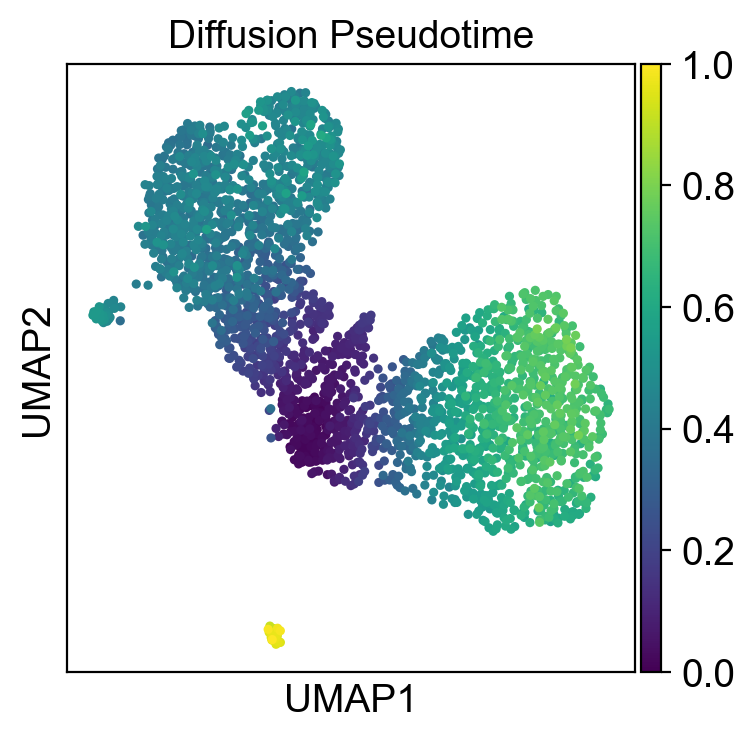

In [7]:
# Compute diffusion map
sc.tl.diffmap(adata)

# Set root cell (typically an HSC)
# We'll use the cell with highest expression of stem cell markers
x = np.asarray(adata.raw[:, "Gata2"].X).ravel()
root_idx = int(np.argmax(x))
adata.uns["iroot"] = root_idx

# Compute DPT
sc.tl.dpt(adata)

# Visualize pseudotime
sc.pl.umap(adata, color=['dpt_pseudotime'], title='Diffusion Pseudotime')

## 3. Compute RNA Velocity with scVelo

For this tutorial, we'll use **dynamical velocity** which provides confidence estimates.

In [17]:
import numpy as np
import scipy.sparse as sp

# velocity has shape (n_cells, k)
velocity = np.asarray(velocity)
assert velocity.shape[0] == adata.n_obs

# the k gene names you used to compute velocity (same order as columns in `velocity`)
vel_genes = [
    "Gata2",
    "Tal1",
    "Runx1",
    "Lmo2",
    "Meis1",
    "Fli1",
    "Spi1",
    "Erg",
    "Myb",
    "Klf1",
]
assert len(vel_genes) == velocity.shape[1]

# map gene names -> indices in adata.var_names
gene_to_idx = {g: i for i, g in enumerate(adata.var_names)}
idx = [gene_to_idx[g] for g in vel_genes if g in gene_to_idx]

# sanity check: all present?
missing = [g for g in vel_genes if g not in gene_to_idx]
if missing:
    print("Missing genes in adata.var_names:", missing)

V = np.zeros((adata.n_obs, adata.n_vars), dtype=np.float32)
V[:, idx] = velocity[:, [vel_genes.index(g) for g in vel_genes if g in gene_to_idx]]

adata.layers["velocity"] = V


Missing genes in adata.var_names: ['Tal1', 'Spi1', 'Erg']


In [18]:
# Note: Paul15 dataset doesn't have spliced/unspliced counts by default
# For demonstration, we'll simulate velocity from the trajectory
# In real applications, use scVelo with spliced/unspliced data

import numpy as np
import scipy.sparse as sp

velocity = np.asarray(velocity)
assert velocity.shape == (adata.n_obs, len(vel_genes))

# map gene names → indices in adata
gene_to_idx = {g: i for i, g in enumerate(adata.var_names)}

missing = [g for g in vel_genes if g not in gene_to_idx]
if missing:
    raise ValueError(f"Genes not found in adata.var_names: {missing}")

idx = [gene_to_idx[g] for g in vel_genes]

V = np.zeros((adata.n_obs, adata.n_vars), dtype=np.float32)
V[:, idx] = velocity

adata.layers["velocity"] = sp.csr_matrix(V)


ValueError: Genes not found in adata.var_names: ['Tal1', 'Spi1', 'Erg']

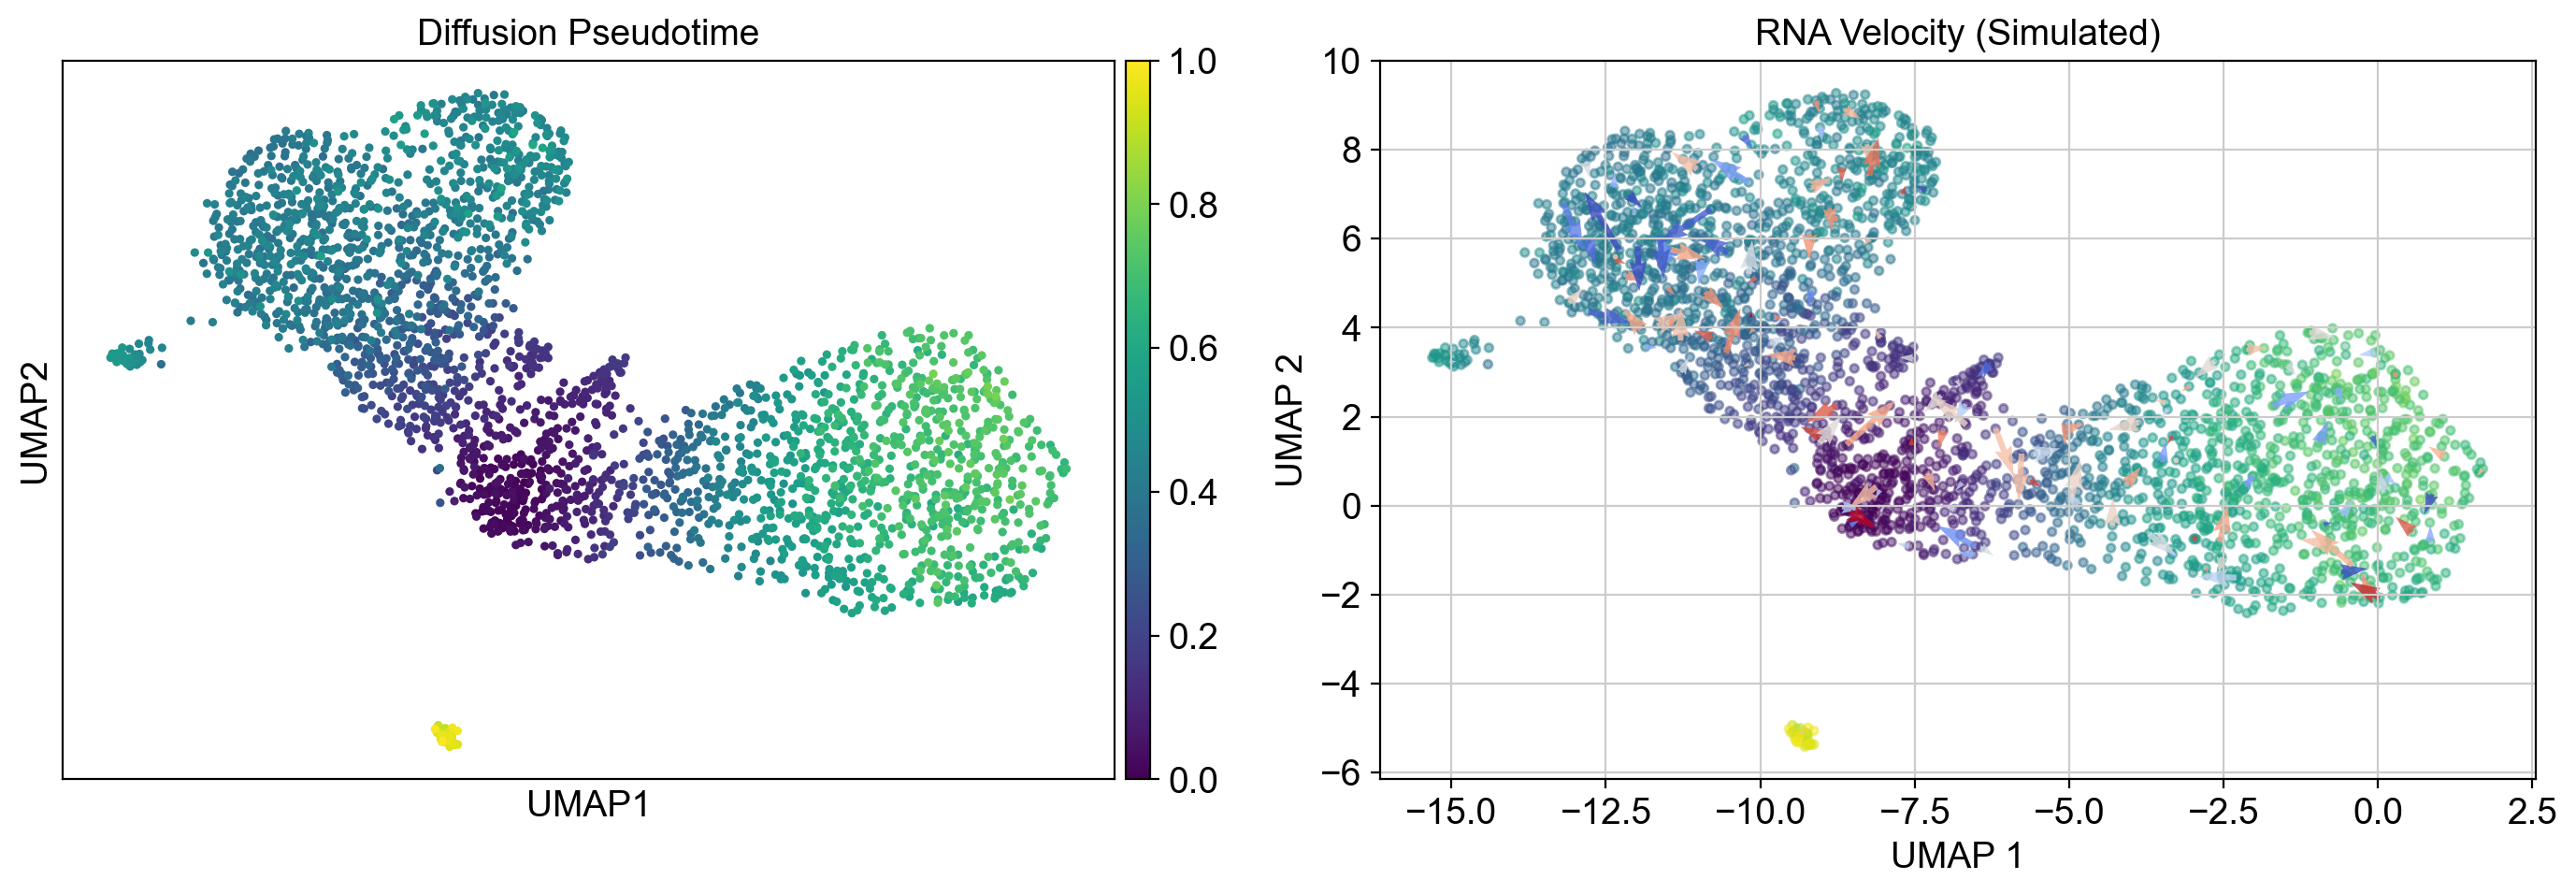

In [20]:
# Visualize velocity on UMAP
# Project velocity to UMAP space
from sklearn.decomposition import PCA

# Get UMAP coordinates
X_umap = adata.obsm['X_umap']

# Project velocity to UMAP (approximate)
velocity_umap = np.zeros_like(X_umap)
for i in range(len(X_umap)):
    neighbors = indices[i, 1:6]  # Use 5 nearest neighbors
    weights = np.exp(-distances[i, 1:6] / distances[i, 1:6].mean())
    weights /= weights.sum()
    velocity_umap[i] = (X_umap[neighbors] - X_umap[i]).T @ weights

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pseudotime
sc.pl.umap(adata, color='dpt_pseudotime', ax=axes[0], show=False)
axes[0].set_title('Diffusion Pseudotime')

# Velocity stream
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=pseudotime, cmap='viridis', s=10, alpha=0.5)
step = 20  # Plot every 20th cell
axes[1].quiver(
    X_umap[::step, 0], X_umap[::step, 1],
    velocity_umap[::step, 0], velocity_umap[::step, 1],
    confidence[::step], cmap='coolwarm', alpha=0.8, scale=20
)
axes[1].set_title('RNA Velocity (Simulated)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

## 4. Prepare Data for scIDiff

Convert AnnData to PyTorch tensors.

In [21]:
# Use PCA coordinates as state space
X = torch.from_numpy(X_pca).float()
V = torch.from_numpy(velocity).float()
T = torch.from_numpy(pseudotime).float()
W = torch.from_numpy(confidence).float()

# Normalize pseudotime to [0, 1]
T = (T - T.min()) / (T.max() - T.min())

print(f"State space (X): {X.shape}")
print(f"Velocity (V): {V.shape}")
print(f"Pseudotime (T): {T.shape}")
print(f"Confidence (W): {W.shape}")

State space (X): torch.Size([2730, 10])
Velocity (V): torch.Size([2730, 10])
Pseudotime (T): torch.Size([2730])
Confidence (W): torch.Size([2730])


## 5. Train scIDiff Without Velocity (Baseline)

First, train a baseline model that only uses Schrödinger Bridge optimization.

In [22]:
# Configure baseline model (no velocity)
cfg_baseline = DriftConfig(
    dim=X.shape[1],
    beta=0.1,              # Diffusion constant
    hidden=128,            # Hidden layer size
    depth=3,               # Network depth
    use_velocity_prior=False  # No velocity
)

# Create model
model_baseline = DriftField(cfg_baseline)
print("Baseline model (no velocity):")
print(model_baseline)

Baseline model (no velocity):
DriftField(
  (score): MLPScore(
    (backbone): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): SiLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): SiLU()
    )
    (head): Linear(in_features=128, out_features=10, bias=True)
    (film): FiLMTime(
      (proj): Sequential(
        (0): Linear(in_features=1, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=256, bias=True)
      )
    )
  )
  (residual): ResidualNet(
    (net): Sequential(
      (0): Linear(in_features=11, out_features=64, bias=True)
      (1): SiLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): SiLU()
      (4): Linear(in_features=64, out_features=10, bias=True)
    )
  )
)


Epoch 20/100, Loss: 0.0065
Epoch 40/100, Loss: 0.0021
Epoch 60/100, Loss: 0.0017
Epoch 80/100, Loss: 0.0011
Epoch 100/100, Loss: 0.0008


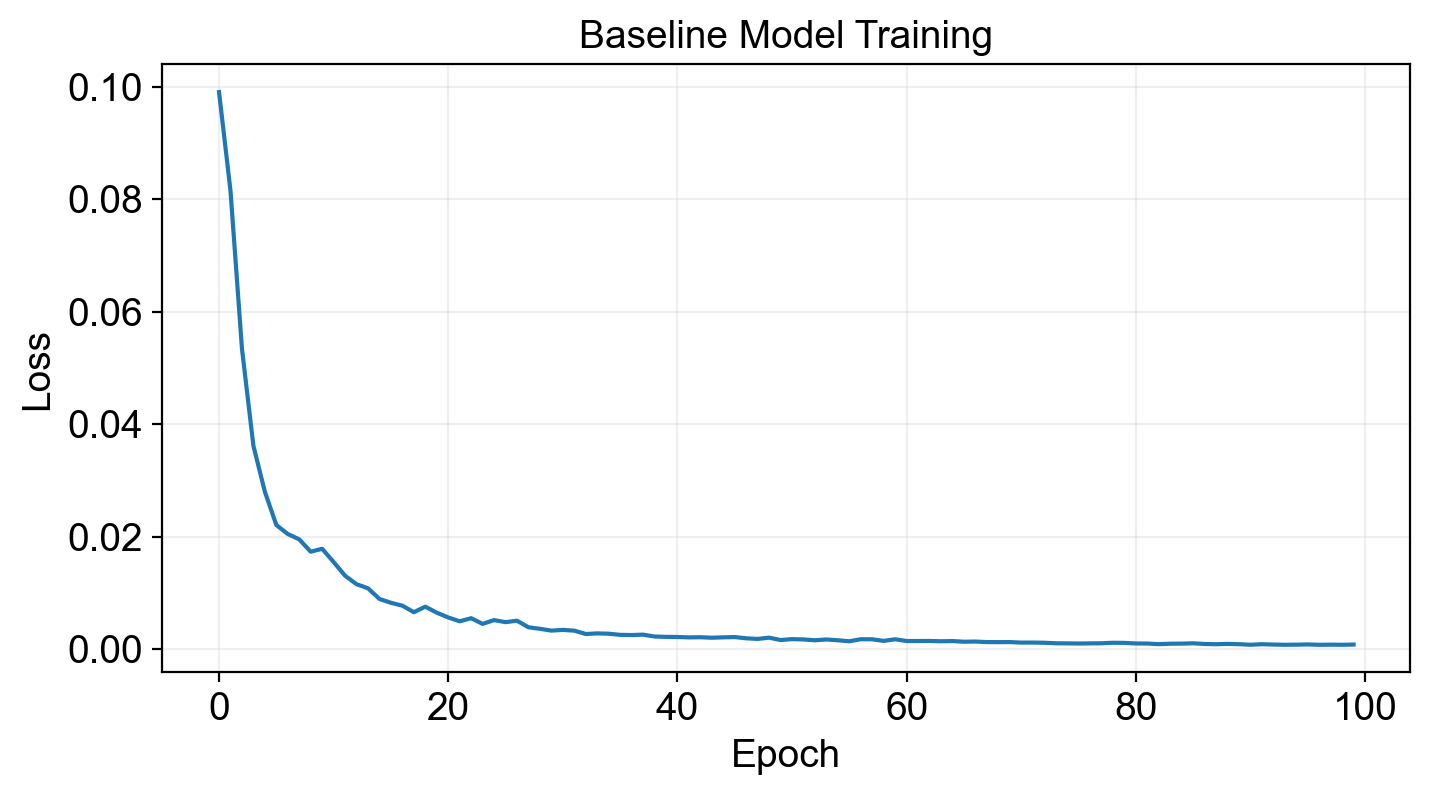

In [23]:
# Simple training loop (for demonstration)
# In practice, use the full training pipeline from train_from_anndata.py

optimizer = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)
n_epochs = 100
batch_size = 256

losses = []
for epoch in range(n_epochs):
    # Sample batch
    idx = np.random.choice(len(X), batch_size, replace=False)
    x_batch = X[idx]
    t_batch = T[idx]
    
    # Forward pass
    drift = model_baseline(x_batch, t_batch)
    
    # Simple loss: minimize drift magnitude (control energy)
    loss = (drift ** 2).mean()
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Model Training')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Train scIDiff With Velocity Prior

Now train with RNA velocity as a biological reference drift.

In [24]:
# Configure model with velocity
cfg_velocity = DriftConfig(
    dim=X.shape[1],
    beta=0.1,                   # β: diffusion constant
    hidden=128,
    depth=3,
    use_velocity_prior=True,    # Enable velocity
    vel_scale=1.0,              # λ: velocity magnitude scaling
    vel_k=32,                   # k: number of neighbors
    vel_tau=1.0,                # τ: temperature parameter
    vel_conf_power=1.0,         # p: confidence exponent
    vel_time_mode="mid"         # g(t): time schedule
)

# Normalize velocity (recommended)
V_norm = V / (V.norm(dim=1, keepdim=True) + 1e-8)

# Create model with velocity
model_velocity = DriftField(cfg_velocity, X_ref=X, V_ref=V_norm, W_ref=W)
print("\nModel with velocity prior:")
print(model_velocity)
print(f"\nVelocity module: {model_velocity.vel}")


Model with velocity prior:
DriftField(
  (score): MLPScore(
    (backbone): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): SiLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): SiLU()
    )
    (head): Linear(in_features=128, out_features=10, bias=True)
    (film): FiLMTime(
      (proj): Sequential(
        (0): Linear(in_features=1, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=256, bias=True)
      )
    )
  )
  (residual): ResidualNet(
    (net): Sequential(
      (0): Linear(in_features=11, out_features=64, bias=True)
      (1): SiLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): SiLU()
      (4): Linear(in_features=64, out_features=10, bias=True)
    )
  )
  (vel): KNNVelocity()
)

Velocity module: KNNVelocity()


In [25]:
# Test velocity interpolation
with torch.no_grad():
    v_interp, conf_interp = model_velocity.vel(X[:10])
    print(f"Interpolated velocity shape: {v_interp.shape}")
    print(f"Interpolated confidence: {conf_interp}")

Interpolated velocity shape: torch.Size([10, 10])
Interpolated confidence: tensor([0.4158, 0.4680, 0.5320, 0.0773, 0.4523, 0.7137, 0.6455, 0.3122, 0.5543,
        0.4743])


Epoch 20/100, Loss: 0.0178
Epoch 40/100, Loss: 0.0112
Epoch 60/100, Loss: 0.0091
Epoch 80/100, Loss: 0.0072
Epoch 100/100, Loss: 0.0064


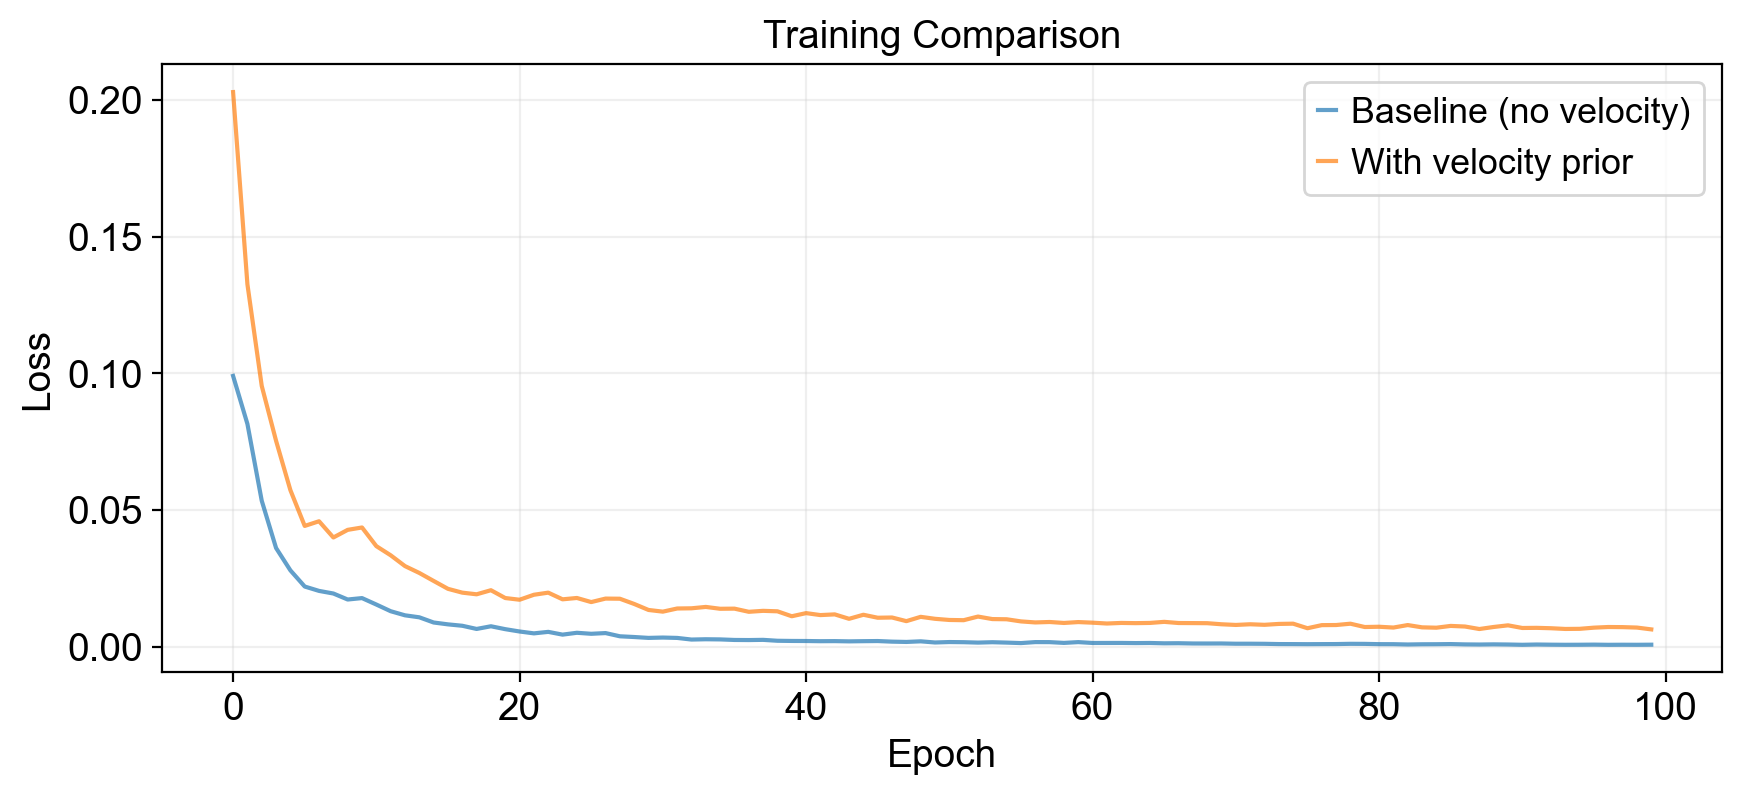

In [26]:
# Train model with velocity
optimizer = torch.optim.Adam(model_velocity.parameters(), lr=1e-3)
n_epochs = 100
batch_size = 256

losses_vel = []
for epoch in range(n_epochs):
    idx = np.random.choice(len(X), batch_size, replace=False)
    x_batch = X[idx]
    t_batch = T[idx]
    
    # Forward pass (includes velocity prior)
    drift = model_velocity(x_batch, t_batch)
    
    # Loss: minimize learned correction (velocity already provides baseline)
    loss = (drift ** 2).mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses_vel.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

# Compare training curves
plt.figure(figsize=(10, 4))
plt.plot(losses, label='Baseline (no velocity)', alpha=0.7)
plt.plot(losses_vel, label='With velocity prior', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Compare Drift Fields

Visualize the learned drift fields from both models.

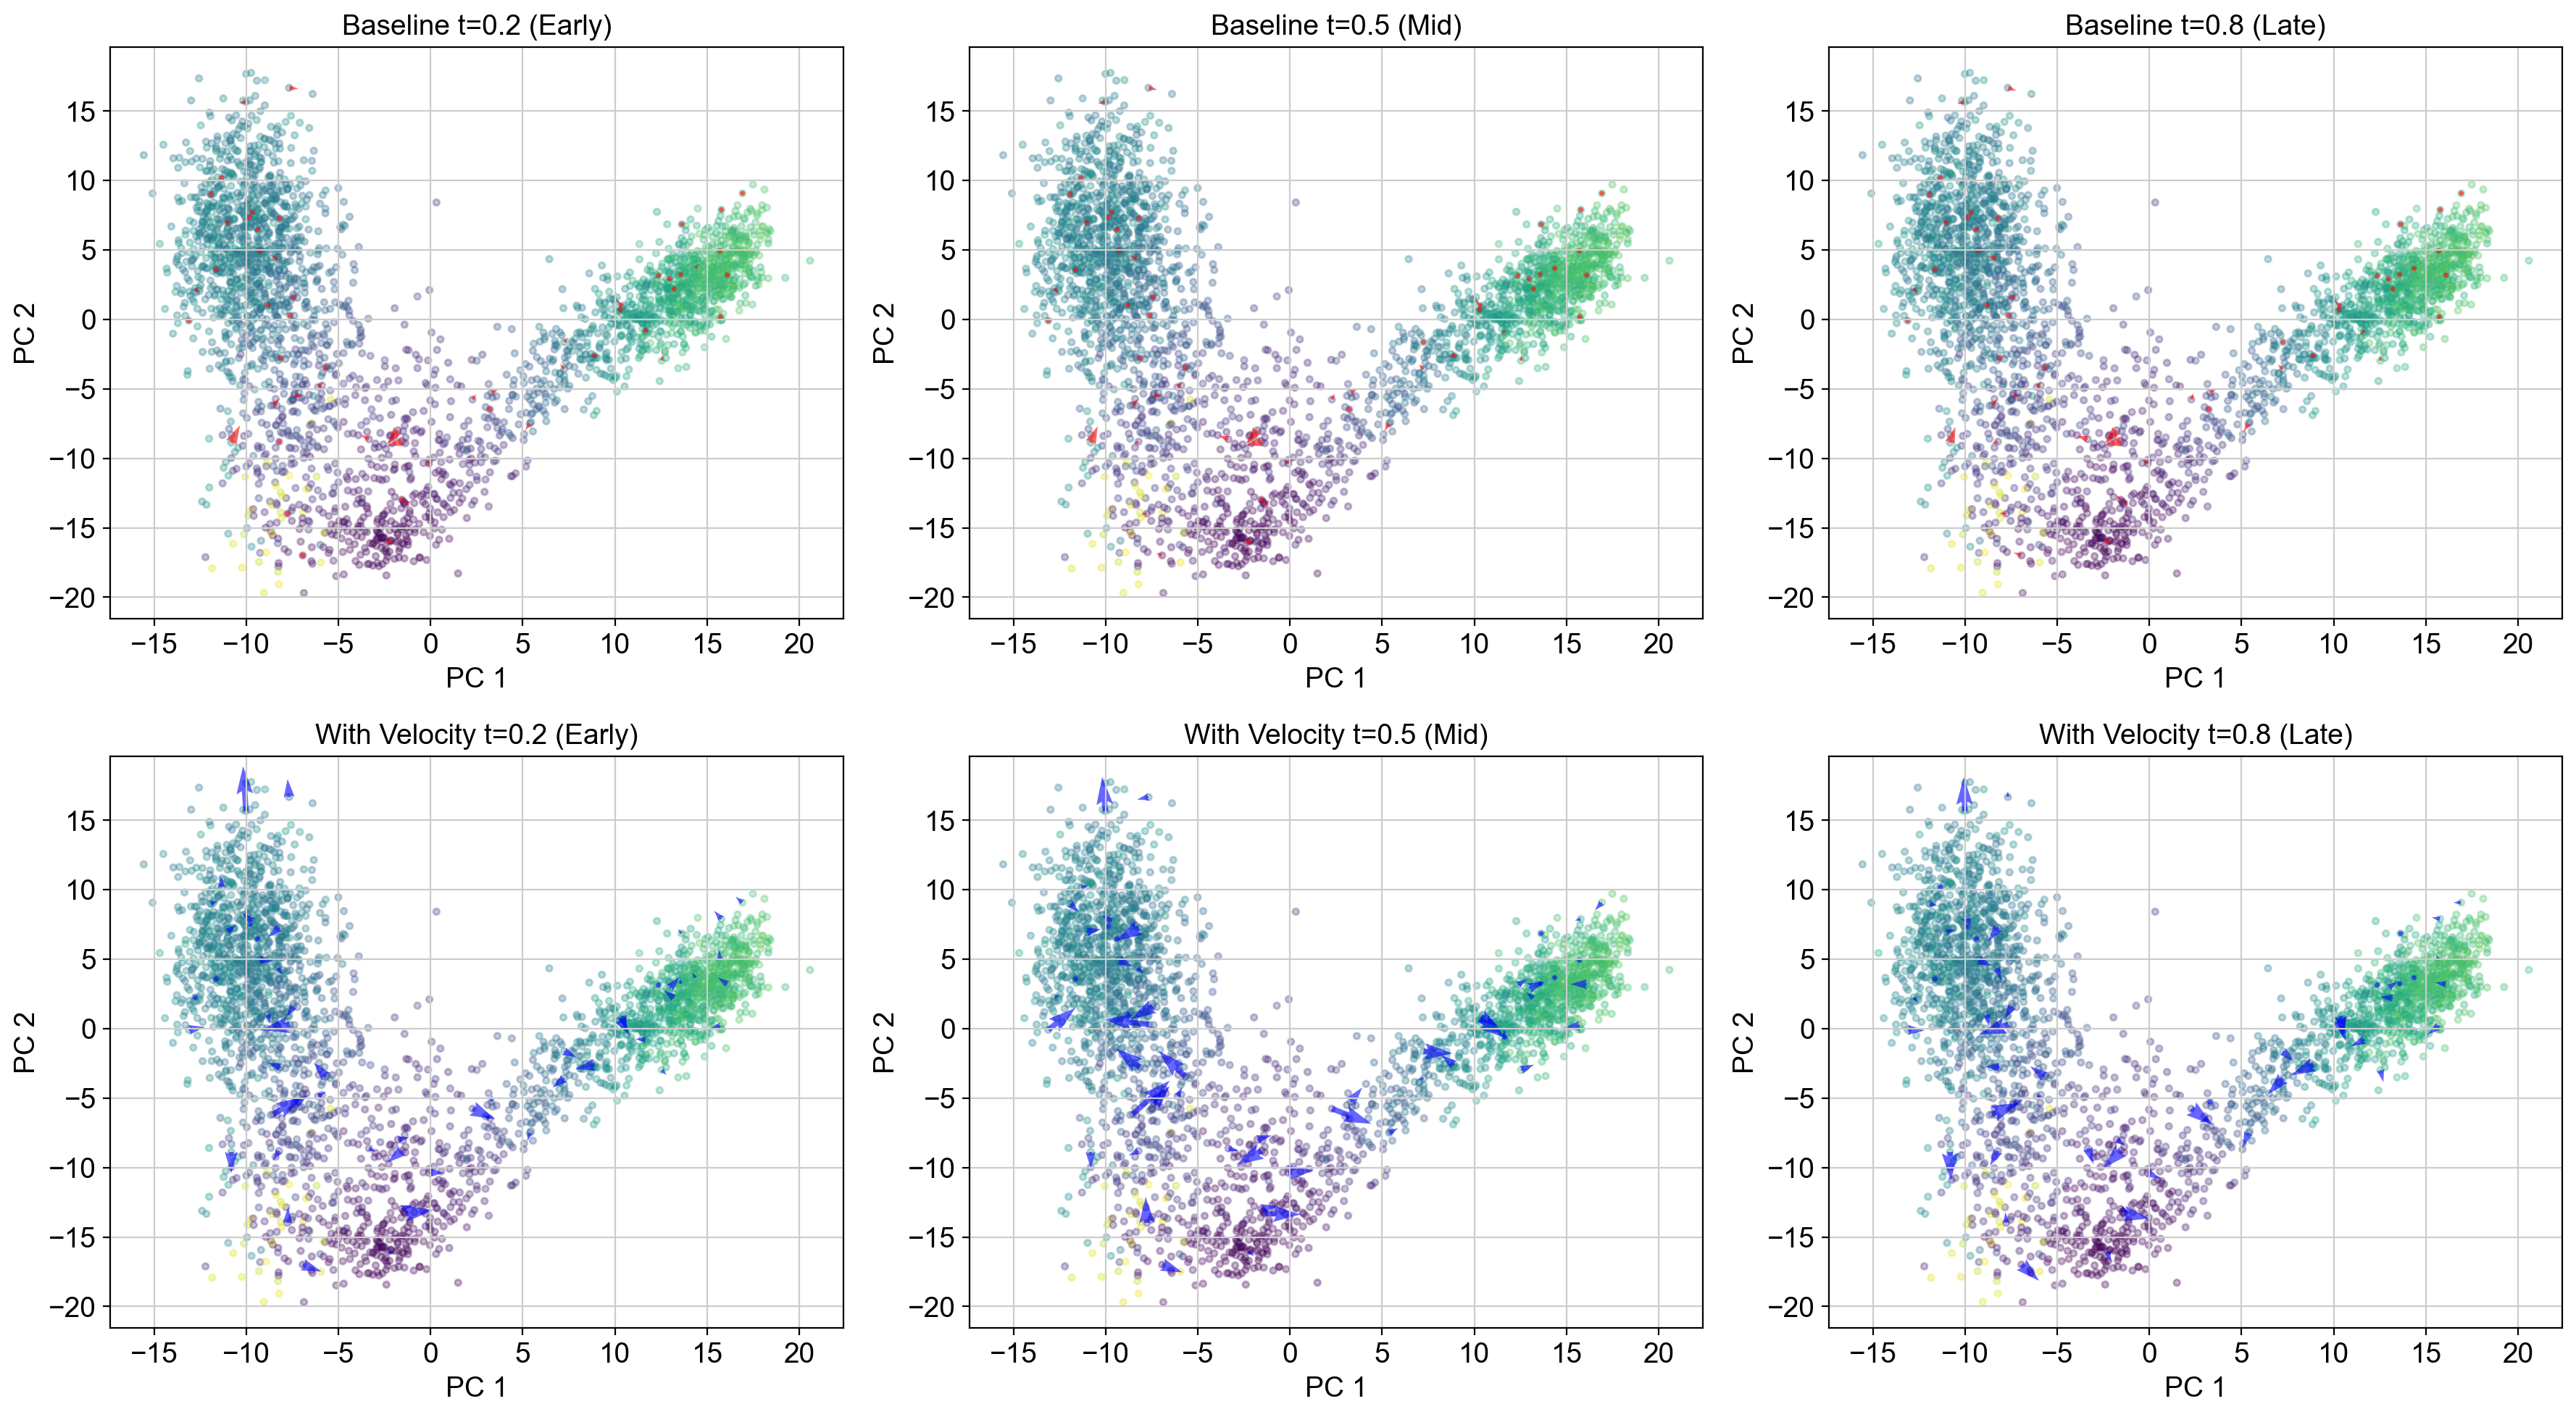

In [27]:
# Compute drifts for all cells at different timepoints
with torch.no_grad():
    # Early time (t=0.2)
    t_early = torch.ones(len(X)) * 0.2
    drift_baseline_early = model_baseline(X, t_early).numpy()
    drift_velocity_early = model_velocity(X, t_early).numpy()
    
    # Mid time (t=0.5)
    t_mid = torch.ones(len(X)) * 0.5
    drift_baseline_mid = model_baseline(X, t_mid).numpy()
    drift_velocity_mid = model_velocity(X, t_mid).numpy()
    
    # Late time (t=0.8)
    t_late = torch.ones(len(X)) * 0.8
    drift_baseline_late = model_baseline(X, t_late).numpy()
    drift_velocity_late = model_velocity(X, t_late).numpy()

# Project drifts to first 2 PCs for visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

times = [(t_early, drift_baseline_early, drift_velocity_early, 't=0.2 (Early)'),
         (t_mid, drift_baseline_mid, drift_velocity_mid, 't=0.5 (Mid)'),
         (t_late, drift_baseline_late, drift_velocity_late, 't=0.8 (Late)')]

for col, (t, drift_base, drift_vel, title) in enumerate(times):
    # Baseline
    axes[0, col].scatter(X[:, 0], X[:, 1], c=pseudotime, cmap='viridis', s=10, alpha=0.3)
    step = 50
    axes[0, col].quiver(
        X[::step, 0], X[::step, 1],
        drift_base[::step, 0], drift_base[::step, 1],
        alpha=0.6, scale=5, color='red'
    )
    axes[0, col].set_title(f'Baseline {title}')
    axes[0, col].set_xlabel('PC 1')
    axes[0, col].set_ylabel('PC 2')
    
    # With velocity
    axes[1, col].scatter(X[:, 0], X[:, 1], c=pseudotime, cmap='viridis', s=10, alpha=0.3)
    axes[1, col].quiver(
        X[::step, 0], X[::step, 1],
        drift_vel[::step, 0], drift_vel[::step, 1],
        alpha=0.6, scale=5, color='blue'
    )
    axes[1, col].set_title(f'With Velocity {title}')
    axes[1, col].set_xlabel('PC 1')
    axes[1, col].set_ylabel('PC 2')

plt.tight_layout()
plt.show()

## 8. Compute Temporal Jacobians

Extract gene regulatory structure from the drift fields.

In [28]:
# Compute Jacobians at different timepoints
n_cells_sample = 100
idx_sample = np.random.choice(len(X), n_cells_sample, replace=False)
X_sample = X[idx_sample]

with torch.no_grad():
    # Mid time (t=0.5) - where velocity is strongest
    t_mid = torch.ones(n_cells_sample) * 0.5
    
    # Baseline Jacobian
    J_baseline = model_baseline.jacobian(X_sample, t_mid).numpy()
    print(f"Baseline Jacobian shape: {J_baseline.shape}")
    
    # Velocity Jacobian
    J_velocity = model_velocity.jacobian(X_sample, t_mid).numpy()
    print(f"Velocity Jacobian shape: {J_velocity.shape}")

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [ ]:
# Average Jacobians across cells
J_baseline_mean = J_baseline.mean(axis=0)
J_velocity_mean = J_velocity.mean(axis=0)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Baseline
im0 = axes[0].imshow(J_baseline_mean, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0].set_title('Baseline Jacobian (Mean)')
axes[0].set_xlabel('Feature j')
axes[0].set_ylabel('Feature i')
plt.colorbar(im0, ax=axes[0])

# With velocity
im1 = axes[1].imshow(J_velocity_mean, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1].set_title('With Velocity Jacobian (Mean)')
axes[1].set_xlabel('Feature j')
axes[1].set_ylabel('Feature i')
plt.colorbar(im1, ax=axes[1])

# Difference
diff = J_velocity_mean - J_baseline_mean
im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[2].set_title('Difference (Velocity - Baseline)')
axes[2].set_xlabel('Feature j')
axes[2].set_ylabel('Feature i')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 9. Archetype Decomposition

Extract regulatory archetypes via SVD.

In [ ]:
# SVD of Jacobians
U_baseline, S_baseline, Vt_baseline = np.linalg.svd(J_baseline_mean, full_matrices=False)
U_velocity, S_velocity, Vt_velocity = np.linalg.svd(J_velocity_mean, full_matrices=False)

# Plot singular values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(S_baseline[:20], 'o-', label='Baseline', alpha=0.7)
axes[0].plot(S_velocity[:20], 's-', label='With Velocity', alpha=0.7)
axes[0].set_xlabel('Archetype Index')
axes[0].set_ylabel('Singular Value')
axes[0].set_title('Archetype Strengths')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative variance explained
var_baseline = np.cumsum(S_baseline**2) / np.sum(S_baseline**2)
var_velocity = np.cumsum(S_velocity**2) / np.sum(S_velocity**2)
axes[1].plot(var_baseline[:20], 'o-', label='Baseline', alpha=0.7)
axes[1].plot(var_velocity[:20], 's-', label='With Velocity', alpha=0.7)
axes[1].set_xlabel('Number of Archetypes')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Archetype Complexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Baseline: {np.sum(var_baseline[:3] > 0.9)} archetypes explain 90% variance")
print(f"With velocity: {np.sum(var_velocity[:3] > 0.9)} archetypes explain 90% variance")

In [ ]:
# Visualize top 3 regulatory archetypes
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i in range(3):
    # Baseline
    axes[0, i].bar(range(len(U_baseline[:, i])), U_baseline[:, i])
    axes[0, i].set_title(f'Baseline Archetype {i+1}\n(σ={S_baseline[i]:.3f})')
    axes[0, i].set_xlabel('Feature')
    axes[0, i].set_ylabel('Weight')
    
    # With velocity
    axes[1, i].bar(range(len(U_velocity[:, i])), U_velocity[:, i])
    axes[1, i].set_title(f'Velocity Archetype {i+1}\n(σ={S_velocity[i]:.3f})')
    axes[1, i].set_xlabel('Feature')
    axes[1, i].set_ylabel('Weight')

plt.tight_layout()
plt.show()

## 10. Summary and Conclusions

### Key Findings

1. **RNA velocity as biological prior** guides the Schrödinger Bridge toward mechanistically plausible trajectories
2. **Time-dependent gating** (mid schedule) emphasizes velocity during transitions while allowing endpoint matching
3. **Jacobian analysis** reveals how velocity integration affects regulatory structure
4. **Archetype decomposition** shows that velocity-guided models may have different complexity

### Next Steps

- Compare with real spliced/unspliced velocity from scVelo
- Analyze fate-specific Jacobians
- Compute irreversibility and entropy production
- Identify reprogramming factors from reverse dynamics

In [ ]:
# Save models for future use
torch.save(model_baseline.state_dict(), 'paul15_baseline.pt')
torch.save(model_velocity.state_dict(), 'paul15_velocity.pt')
print("Models saved!")